In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#334155',
    'axes.labelcolor':  '#e2e8f0',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#e2e8f0',
    'grid.color':       '#334155',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.size':        11,
})
PALETTE = ['#38bdf8', '#f472b6', '#34d399', '#fbbf24', '#a78bfa', '#fb923c']
print('✅ Libraries loaded')

✅ Libraries loaded


In [11]:
import os
print(os.getcwd())

C:\Users\sanda\webmobi demanding task


In [31]:
print(os.listdir('dataset'))

['calendar.csv', 'customers.csv', 'products.csv', 'sales.csv', 'stores.csv']


In [34]:
import pandas as pd
import os

# Check files
print("Files in dataset folder:", os.listdir('dataset'))

# ── Load all datasets (CSV) ──
sales = pd.read_csv('dataset/sales.csv', parse_dates=['order_date'])
products = pd.read_csv('dataset/products.csv')
stores = pd.read_csv('dataset/stores.csv')
customers = pd.read_csv('dataset/customers.csv', parse_dates=['join_date'])
calendar = pd.read_csv('dataset/calendar.csv', parse_dates=['date'])

# ── Basic Info ──
print(f"\nSales     : {sales.shape[0]:,} rows × {sales.shape[1]} cols")
print(f"Products  : {products.shape[0]:,} rows × {products.shape[1]} cols")
print(f"Stores    : {stores.shape[0]:,} rows × {stores.shape[1]} cols")
print(f"Customers : {customers.shape[0]:,} rows × {customers.shape[1]} cols")
print(f"Calendar  : {calendar.shape[0]:,} rows × {calendar.shape[1]} cols")

# ── Date Range ──
print(f"\nDate range: {sales['order_date'].min().date()} → {sales['order_date'].max().date()}")

# ── Key Metrics ──
print(f"Total Revenue: ${sales['revenue'].sum():,.2f}")
print(f"Total Units Sold: {sales['quantity'].sum():,}")

Files in dataset folder: ['calendar.csv', 'customers.csv', 'products.csv', 'sales.csv', 'stores.csv']

Sales     : 1,000,000 rows × 11 cols
Products  : 200 rows × 6 cols
Stores    : 100 rows × 5 cols
Customers : 50,000 rows × 5 cols
Calendar  : 731 rows × 6 cols

Date range: 2023-01-01 → 2024-12-31
Total Revenue: $25,486,128.86
Total Units Sold: 2,999,589


In [36]:
# ── Preview each dataset ──
print("=== SALES ===")
display(sales.head(3))
print("\n=== PRODUCTS ===")
display(products.head(3))
print("\n=== STORES ===")
display(stores.head(3))

=== SALES ===


,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75



=== PRODUCTS ===


,product_id,product_name,brand,category,cocoa_percent,weight_g
0,P0001,White Chocolate 80%,Mars,Truffle,80,120
1,P0002,Dark Chocolate 70%,Cadbury,Praline,70,100
2,P0003,Truffle Chocolate 70%,Hershey,Praline,70,120



=== STORES ===


,store_id,store_name,city,country,store_type
0,S001,Chocolate Store 1,New York,Canada,Retail
1,S002,Chocolate Store 2,Melbourne,Canada,Mall
2,S003,Chocolate Store 3,Berlin,France,Mall


In [38]:
# ── Missing values & data types ──
print("Missing values in SALES:")
print(sales.isnull().sum())
print("\nData types:")
print(sales.dtypes)
print("\nSales descriptive stats:")
display(sales[['quantity','unit_price','discount','revenue','cost','profit']].describe().round(2))

Missing values in SALES:
order_id       0
order_date     0
product_id     0
store_id       0
customer_id    0
quantity       0
unit_price     0
discount       0
revenue        0
cost           0
profit         0
dtype: int64

Data types:
order_id               object
order_date     datetime64[ns]
product_id             object
store_id               object
customer_id            object
quantity                int64
unit_price            float64
discount              float64
revenue               float64
cost                  float64
profit                float64
dtype: object

Sales descriptive stats:


,quantity,unit_price,discount,revenue,cost,profit
count,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00
mean,3.00,9.00,0.06,25.49,15.29,10.19
std,1.41,3.46,0.08,16.37,9.97,6.78
min,1.00,3.00,0.00,2.40,1.20,0.73
25%,2.00,6.00,0.00,12.16,7.24,4.78
50%,3.00,9.01,0.00,21.92,13.03,8.60
75%,4.00,12.00,0.15,35.88,21.41,14.17
max,5.00,15.00,0.20,75.00,52.43,37.43


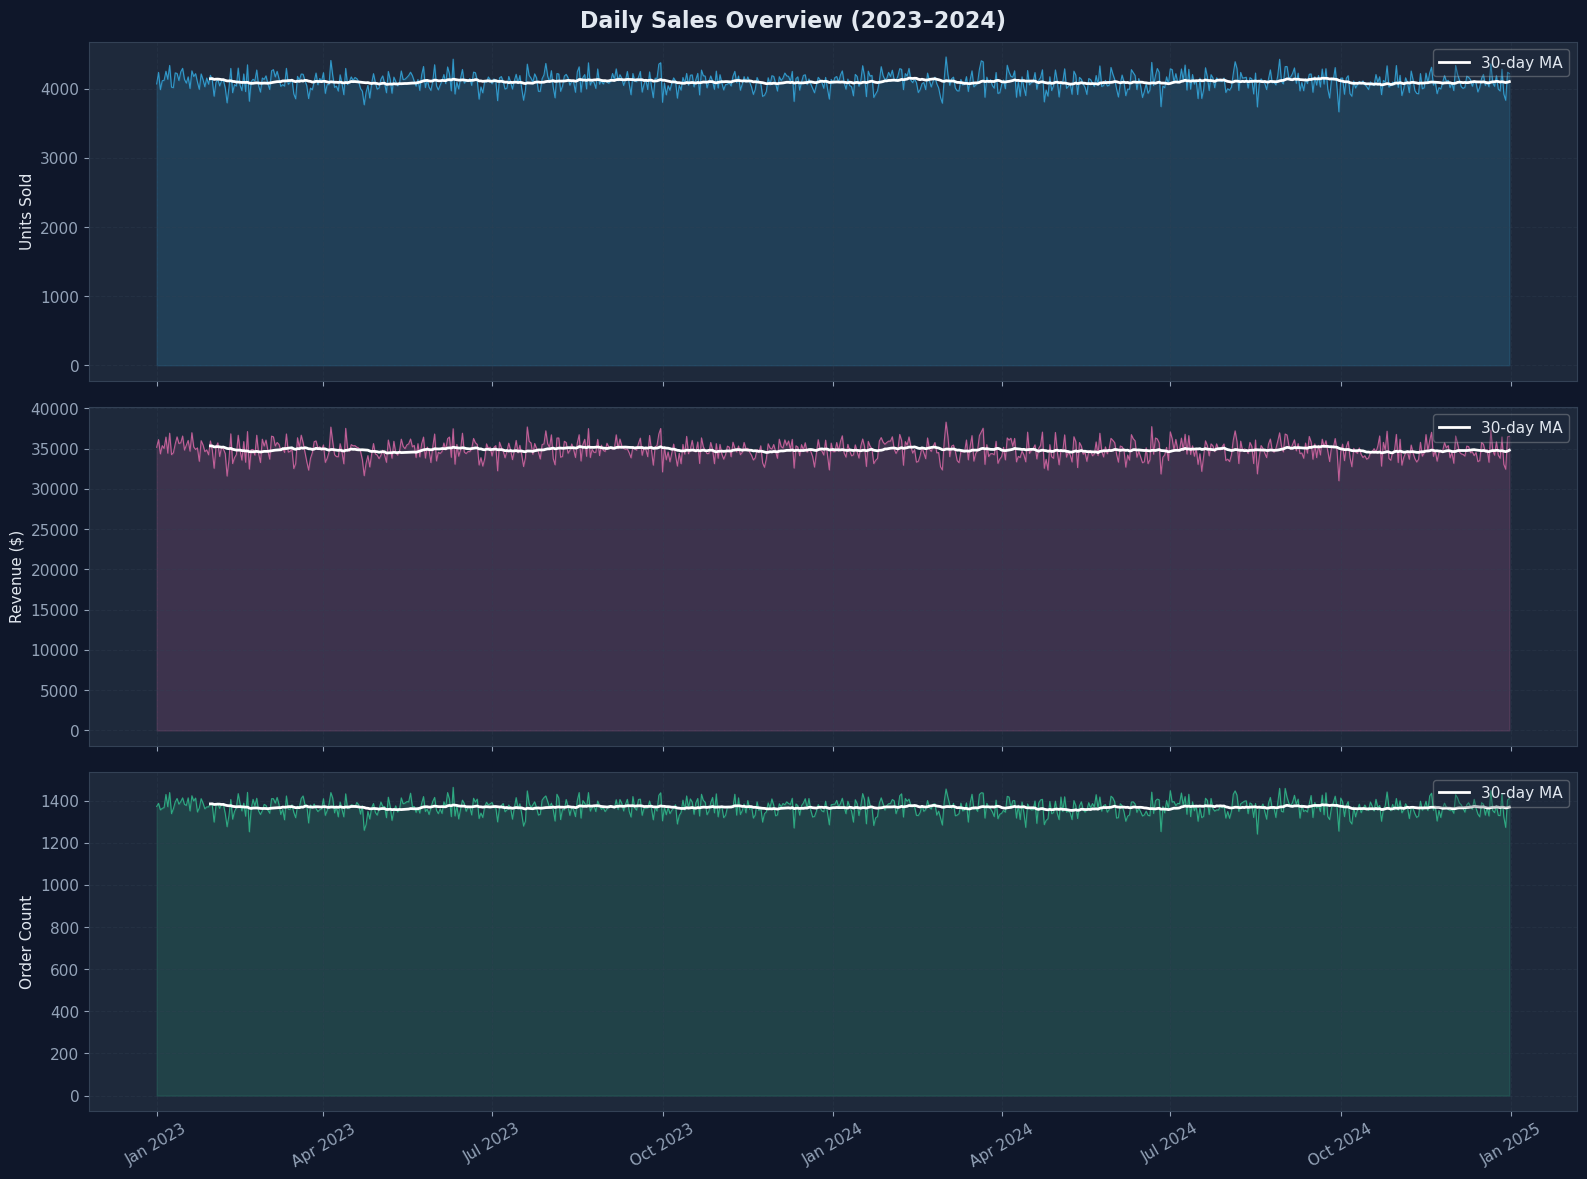

Avg daily demand: 4103 units
Peak day: 2024-03-02 — 4461 units


In [40]:
# ── 3.1 Daily Demand Trend ──
daily = sales.groupby('order_date').agg(
    demand   = ('quantity', 'sum'),
    revenue  = ('revenue',  'sum'),
    orders   = ('order_id', 'count')
).reset_index().sort_values('order_date')

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle('Daily Sales Overview (2023–2024)', fontsize=16, fontweight='bold', y=0.98)

for ax, col, color, label in zip(axes,
    ['demand', 'revenue', 'orders'],
    [PALETTE[0], PALETTE[1], PALETTE[2]],
    ['Units Sold', 'Revenue ($)', 'Order Count']):
    ax.plot(daily['order_date'], daily[col], color=color, linewidth=0.8, alpha=0.7)
    ax.fill_between(daily['order_date'], daily[col], alpha=0.15, color=color)
    # 30-day rolling average
    ax.plot(daily['order_date'], daily[col].rolling(30).mean(), color='white', linewidth=2, label='30-day MA')
    ax.set_ylabel(label, fontsize=11)
    ax.legend(loc='upper right', framealpha=0.3)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('eda_daily_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Avg daily demand: {daily['demand'].mean():.0f} units")
print(f"Peak day: {daily.loc[daily['demand'].idxmax(), 'order_date'].date()} — {daily['demand'].max()} units")

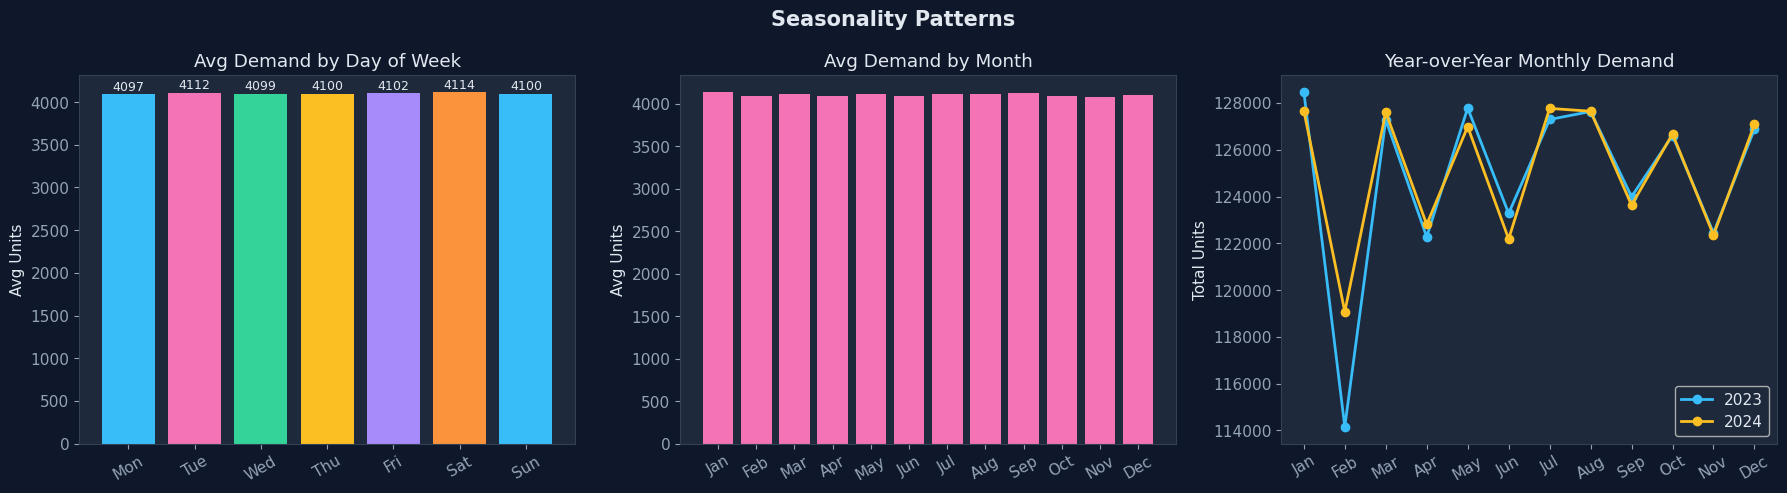

In [42]:
# ── 3.2 Seasonality Analysis ──
daily['dow'] = daily['order_date'].dt.day_name()
daily['month_name'] = daily['order_date'].dt.strftime('%b')
daily['month_num'] = daily['order_date'].dt.month
daily['year'] = daily['order_date'].dt.year

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Seasonality Patterns', fontsize=15, fontweight='bold')

# By day of week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_avg = daily.groupby('dow')['demand'].mean().reindex(dow_order)
bars = axes[0].bar(range(7), dow_avg.values, color=PALETTE[:7])
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=30)
axes[0].set_title('Avg Demand by Day of Week')
axes[0].set_ylabel('Avg Units')
for bar, val in zip(bars, dow_avg.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:.0f}', ha='center', va='bottom', fontsize=9)

# By month
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_avg = daily.groupby('month_name')['demand'].mean().reindex(month_order)
bars2 = axes[1].bar(range(12), month_avg.values, color=PALETTE[1])
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(month_order, rotation=30)
axes[1].set_title('Avg Demand by Month')
axes[1].set_ylabel('Avg Units')

# Year-over-year
monthly_yd = daily.groupby(['year','month_num'])['demand'].sum().reset_index()
for yr, color in zip([2023, 2024], [PALETTE[0], PALETTE[3]]):
    d = monthly_yd[monthly_yd['year'] == yr]
    axes[2].plot(d['month_num'], d['demand'], marker='o', label=str(yr), color=color, linewidth=2)
axes[2].set_xticks(range(1,13))
axes[2].set_xticklabels(month_order, rotation=30)
axes[2].set_title('Year-over-Year Monthly Demand')
axes[2].set_ylabel('Total Units')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

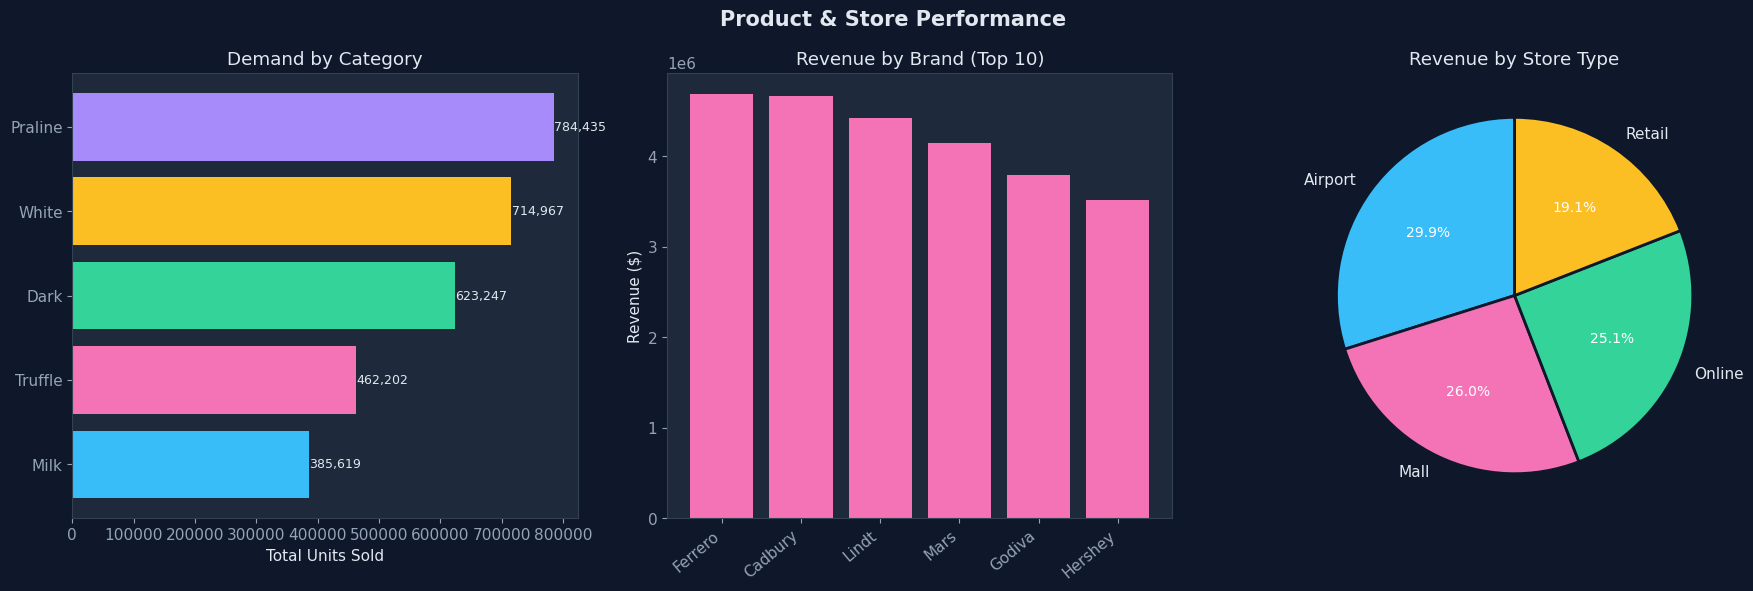

In [45]:
# ── 3.3 Category & Brand Analysis ──
sales_full = sales.merge(products, on='product_id').merge(stores, on='store_id')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Product & Store Performance', fontsize=15, fontweight='bold')

# Category demand share
cat_demand = sales_full.groupby('category')['quantity'].sum().sort_values(ascending=True)
colors_pie = PALETTE[:len(cat_demand)]
axes[0].barh(cat_demand.index, cat_demand.values, color=colors_pie)
axes[0].set_title('Demand by Category')
axes[0].set_xlabel('Total Units Sold')
for i, v in enumerate(cat_demand.values):
    axes[0].text(v + 1000, i, f'{v:,}', va='center', fontsize=9)

# Brand revenue
brand_rev = sales_full.groupby('brand')['revenue'].sum().sort_values(ascending=False).head(10)
axes[1].bar(range(len(brand_rev)), brand_rev.values, color=PALETTE[1])
axes[1].set_xticks(range(len(brand_rev)))
axes[1].set_xticklabels(brand_rev.index, rotation=40, ha='right')
axes[1].set_title('Revenue by Brand (Top 10)')
axes[1].set_ylabel('Revenue ($)')

# Store type
stype = sales_full.groupby('store_type')['revenue'].sum()
wedges, texts, autotexts = axes[2].pie(
    stype.values, labels=stype.index, autopct='%1.1f%%',
    colors=PALETTE[:len(stype)], startangle=90,
    wedgeprops={'linewidth': 2, 'edgecolor': '#0f172a'}
)
for at in autotexts:
    at.set_color('white'); at.set_fontsize(10)
axes[2].set_title('Revenue by Store Type')

plt.tight_layout()
plt.savefig('eda_categories.png', dpi=150, bbox_inches='tight')
plt.show()

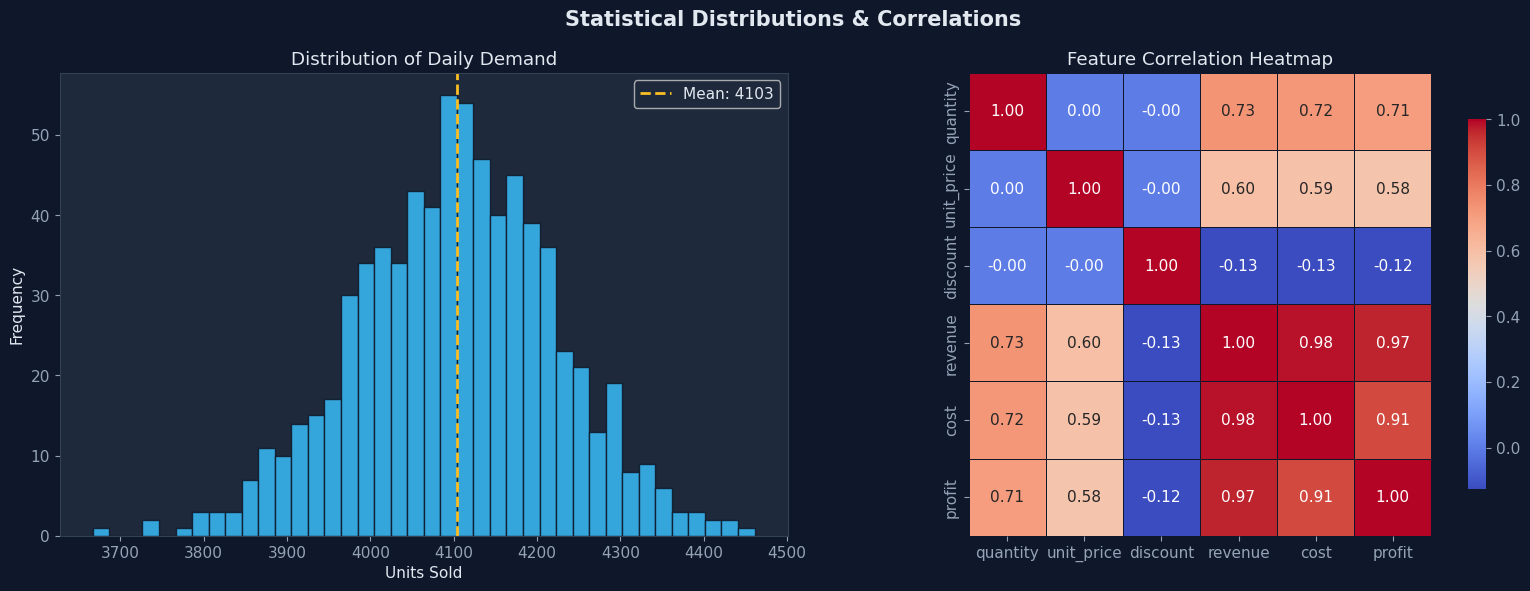

In [47]:
# ── 3.4 Correlation & Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Statistical Distributions & Correlations', fontsize=15, fontweight='bold')

# Distribution of daily demand
axes[0].hist(daily['demand'], bins=40, color=PALETTE[0], edgecolor='#0f172a', alpha=0.85)
mean_d = daily['demand'].mean()
axes[0].axvline(mean_d, color=PALETTE[3], linewidth=2, linestyle='--', label=f'Mean: {mean_d:.0f}')
axes[0].set_title('Distribution of Daily Demand')
axes[0].set_xlabel('Units Sold')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Correlation heatmap
corr_cols = ['quantity','unit_price','discount','revenue','cost','profit']
corr = sales[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, ax=axes[1], annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, linecolor='#0f172a', square=True,
            cbar_kws={'shrink': 0.8})
axes[1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

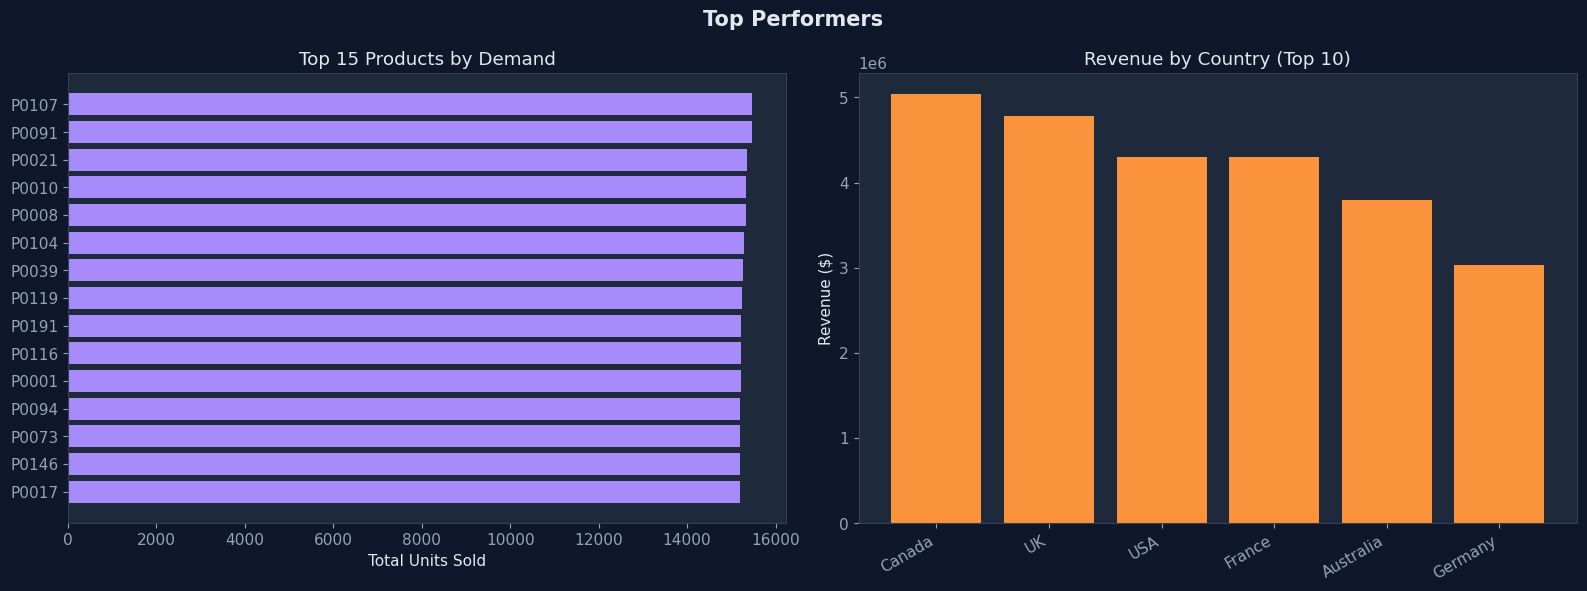

In [50]:
# ── 3.5 Top Products & Countries ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top Performers', fontsize=15, fontweight='bold')

# Top 15 products
top_prod = (sales_full.groupby(['product_id','product_name'])['quantity']
            .sum().reset_index()
            .sort_values('quantity', ascending=False).head(15))
axes[0].barh(top_prod['product_id'][::-1], top_prod['quantity'][::-1], color=PALETTE[4])
axes[0].set_title('Top 15 Products by Demand')
axes[0].set_xlabel('Total Units Sold')

# Revenue by country
country_rev = sales_full.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10)
axes[1].bar(range(len(country_rev)), country_rev.values, color=PALETTE[5])
axes[1].set_xticks(range(len(country_rev)))
axes[1].set_xticklabels(country_rev.index, rotation=30, ha='right')
axes[1].set_title('Revenue by Country (Top 10)')
axes[1].set_ylabel('Revenue ($)')

plt.tight_layout()
plt.savefig('eda_top_performers.png', dpi=150, bbox_inches='tight')
plt.show()

In [54]:
# ── Aggregate to daily level & add all features ──
daily_model = sales.groupby('order_date').agg(
    demand      = ('quantity',   'sum'),
    revenue     = ('revenue',    'sum'),
    orders      = ('order_id',   'count'),
    avg_discount= ('discount',   'mean'),
    avg_price   = ('unit_price', 'mean')
).reset_index().sort_values('order_date').reset_index(drop=True)

# ── Calendar features ──
daily_model['day_of_week'] = daily_model['order_date'].dt.dayofweek
daily_model['month']       = daily_model['order_date'].dt.month
daily_model['quarter']     = daily_model['order_date'].dt.quarter
daily_model['week']        = daily_model['order_date'].dt.isocalendar().week.astype(int)
daily_model['year']        = daily_model['order_date'].dt.year
daily_model['day_of_year'] = daily_model['order_date'].dt.dayofyear
daily_model['is_weekend']  = (daily_model['day_of_week'] >= 5).astype(int)
daily_model['trend']       = range(len(daily_model))  # linear time trend

# ── Lag features (past demand signals) ──
for lag in [1, 7, 14, 30]:
    daily_model[f'lag_{lag}'] = daily_model['demand'].shift(lag)

# ── Rolling statistics ──
for win in [7, 14, 30]:
    daily_model[f'rolling_mean_{win}'] = daily_model['demand'].shift(1).rolling(win).mean()
    daily_model[f'rolling_std_{win}']  = daily_model['demand'].shift(1).rolling(win).std()

# ── Drop NaN rows created by lag/rolling ──
daily_model.dropna(inplace=True)
daily_model.reset_index(drop=True, inplace=True)

print(f"Dataset after feature engineering: {daily_model.shape}")
print(f"Features: {list(daily_model.columns)}")
display(daily_model.head(3))

Dataset after feature engineering: (701, 24)
Features: ['order_date', 'demand', 'revenue', 'orders', 'avg_discount', 'avg_price', 'day_of_week', 'month', 'quarter', 'week', 'year', 'day_of_year', 'is_weekend', 'trend', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_30', 'rolling_std_30']


,order_date,demand,revenue,orders,avg_discount,avg_price,day_of_week,month,quarter,week,...,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_30,rolling_std_30
0,2023-01-31,4126,34807.04,1380,0.057717,9.041652,1,1,1,5,...,4195.0,3992.0,4082.0,4070.0,4112.714286,84.718582,4128.857143,84.609380,4145.333333,95.408499
1,2023-02-01,3893,32562.17,1298,0.051348,8.843274,2,2,1,5,...,4126.0,4215.0,4173.0,4237.0,4131.857143,65.958140,4132.000000,83.545474,4147.200000,94.426545
2,2023-02-02,4095,35210.08,1377,0.054829,9.052869,3,2,1,5,...,3893.0,4134.0,4005.0,3988.0,4085.857143,101.185356,4112.000000,103.988905,4135.733333,103.588021


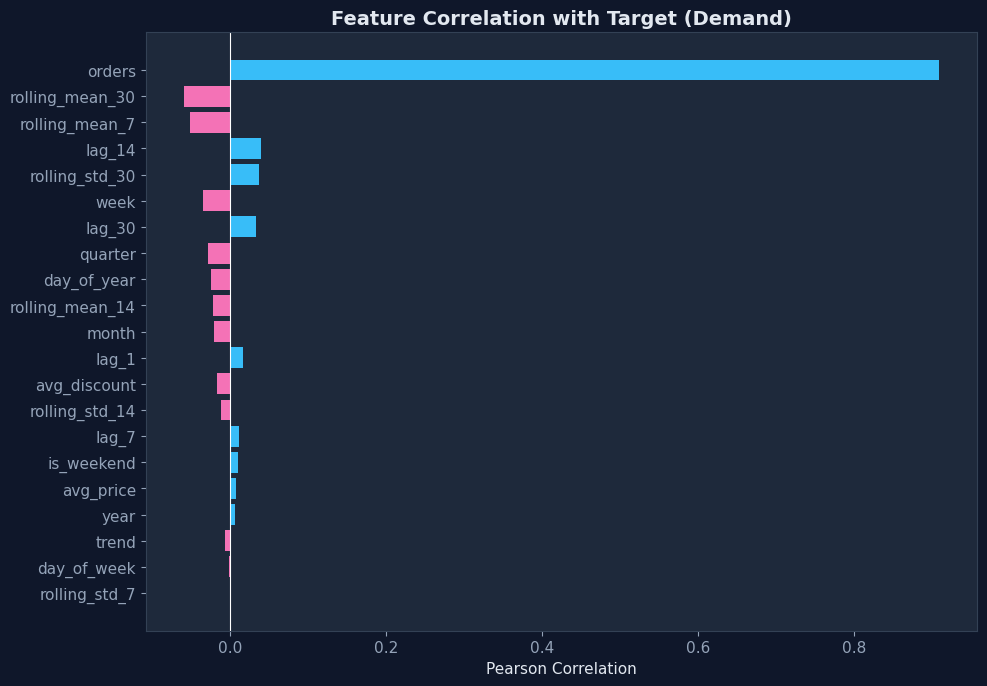

In [56]:
# ── Feature importance preview via correlation ──
feature_cols = ['day_of_week','month','quarter','week','year','day_of_year','is_weekend',
                'trend','avg_discount','avg_price','orders',
                'lag_1','lag_7','lag_14','lag_30',
                'rolling_mean_7','rolling_mean_14','rolling_mean_30',
                'rolling_std_7','rolling_std_14','rolling_std_30']

corr_feat = daily_model[feature_cols + ['demand']].corr()['demand'].drop('demand').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [PALETTE[0] if v >= 0 else PALETTE[1] for v in corr_feat.values]
ax.barh(corr_feat.index[::-1], corr_feat.values[::-1], color=colors[::-1])
ax.axvline(0, color='white', linewidth=0.8)
ax.set_title('Feature Correlation with Target (Demand)', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [58]:
# ── Train/Test Split — last 60 days as test ──
SPLIT_DATE = daily_model['order_date'].max() - pd.Timedelta(days=60)
train = daily_model[daily_model['order_date'] <= SPLIT_DATE].copy()
test  = daily_model[daily_model['order_date'] >  SPLIT_DATE].copy()

X_train, y_train = train[feature_cols], train['demand']
X_test,  y_test  = test[feature_cols],  test['demand']

print(f"Training period : {train['order_date'].min().date()} → {train['order_date'].max().date()} ({len(train)} days)")
print(f"Test period     : {test['order_date'].min().date()} → {test['order_date'].max().date()} ({len(test)} days)")


Training period : 2023-01-31 → 2024-11-01 (641 days)
Test period     : 2024-11-02 → 2024-12-31 (60 days)


In [60]:
# ── Train models ──
models = {
    'Random Forest'     : RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42),
    'Linear Regression' : LinearRegression()
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)
    mape = np.mean(np.abs((y_test.values - pred) / y_test.values)) * 100
    results[name] = {'model': model, 'pred': pred, 'mae': mae, 'rmse': rmse, 'r2': r2, 'mape': mape}
    print(f"{name:22s} → MAE: {mae:.1f}  RMSE: {rmse:.1f}  R²: {r2:.4f}  MAPE: {mape:.2f}%")

best_name = min(results, key=lambda x: results[x]['mae'])
print(f"\n🏆 Best Model: {best_name} (lowest MAE)")

Random Forest          → MAE: 42.3  RMSE: 53.1  R²: 0.7895  MAPE: 1.04%
Gradient Boosting      → MAE: 46.2  RMSE: 59.0  R²: 0.7403  MAPE: 1.13%
Linear Regression      → MAE: 565163939072.5  RMSE: 3095530380982.5  R²: -715136611041848459264.0000  MAPE: 13359324444.57%

🏆 Best Model: Random Forest (lowest MAE)


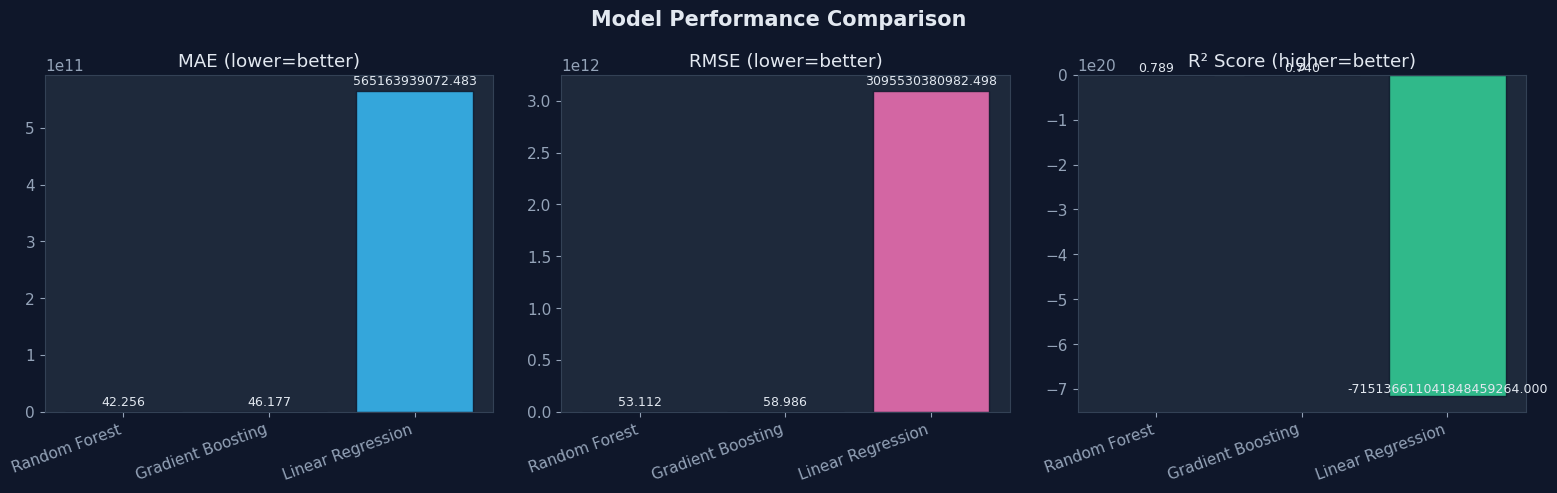

In [63]:
# ── Model Comparison Bar Chart ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')

model_names = list(results.keys())
for ax, metric, label, color in zip(
    axes,
    ['mae', 'rmse', 'r2'],
    ['MAE (lower=better)', 'RMSE (lower=better)', 'R² Score (higher=better)'],
    [PALETTE[0], PALETTE[1], PALETTE[2]]):

    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=color, alpha=0.85, edgecolor='#0f172a')
    ax.set_title(label)
    ax.set_xticklabels(model_names, rotation=20, ha='right')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

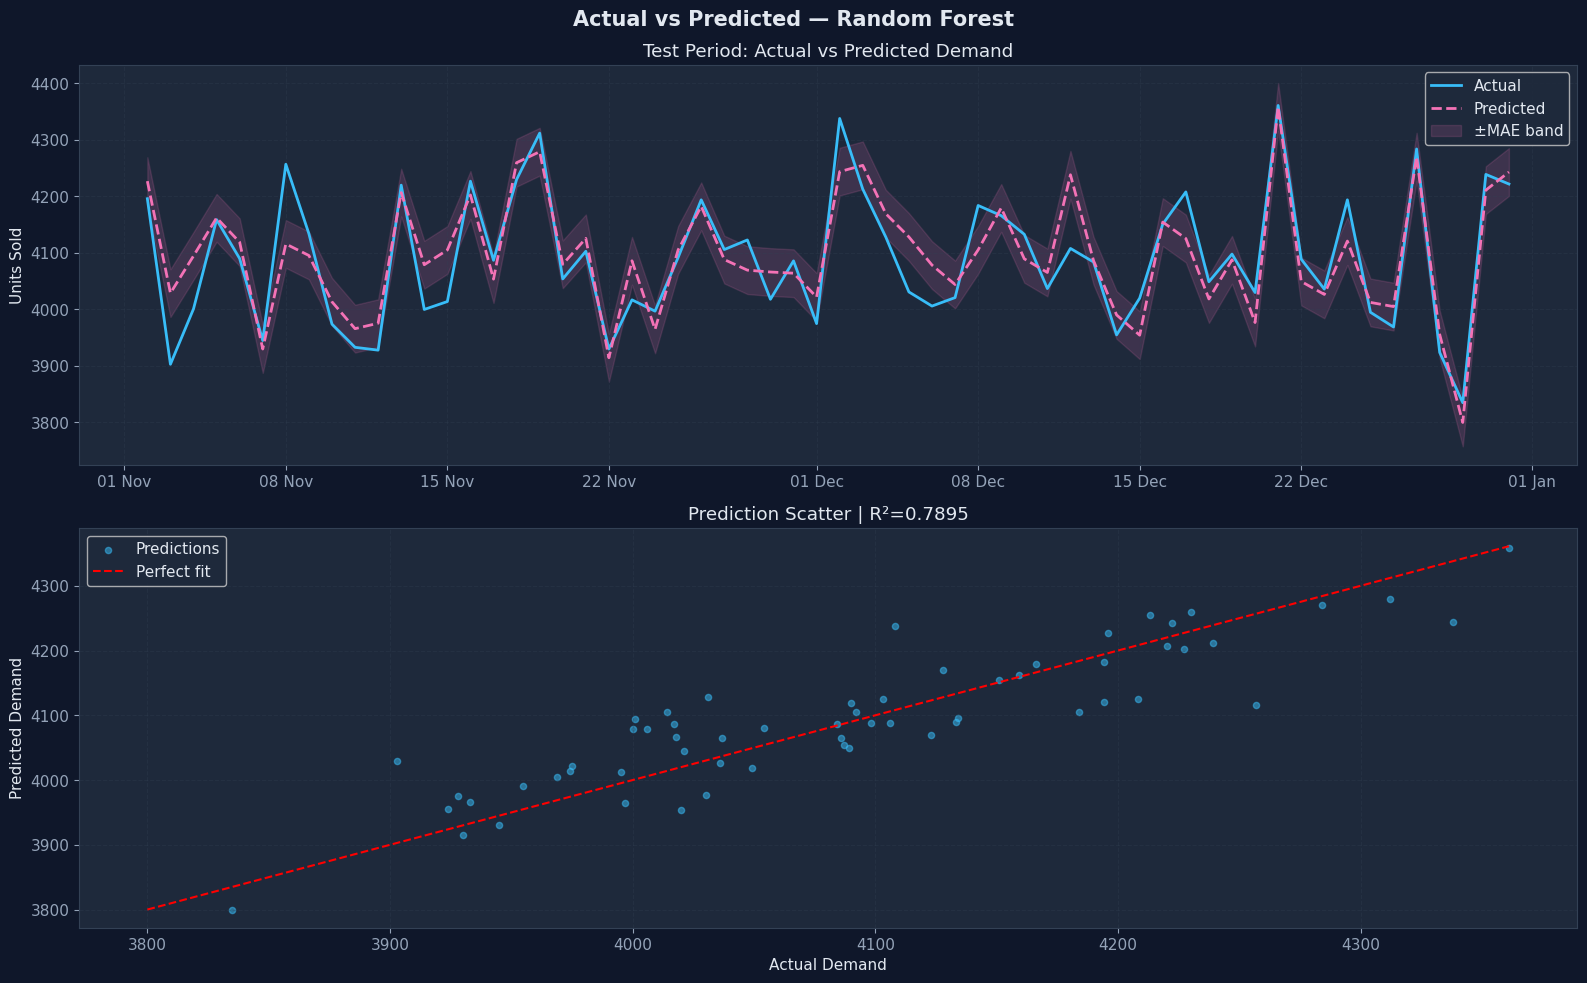

In [66]:
# ── Actual vs Predicted (best model) ──
best_pred = results[best_name]['pred']

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle(f'Actual vs Predicted — {best_name}', fontsize=15, fontweight='bold')

# Time series view
axes[0].plot(test['order_date'], y_test.values,  color=PALETTE[0], label='Actual',    linewidth=2)
axes[0].plot(test['order_date'], best_pred,       color=PALETTE[1], label='Predicted', linewidth=2, linestyle='--')
axes[0].fill_between(test['order_date'],
    best_pred - results[best_name]['mae'],
    best_pred + results[best_name]['mae'],
    alpha=0.15, color=PALETTE[1], label='±MAE band')
axes[0].set_title('Test Period: Actual vs Predicted Demand')
axes[0].set_ylabel('Units Sold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

# Scatter plot
axes[1].scatter(y_test.values, best_pred, alpha=0.5, color=PALETTE[0], s=20, label='Predictions')
min_v, max_v = min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())
axes[1].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5, label='Perfect fit')
axes[1].set_xlabel('Actual Demand')
axes[1].set_ylabel('Predicted Demand')
axes[1].set_title(f'Prediction Scatter | R²={results[best_name]["r2"]:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

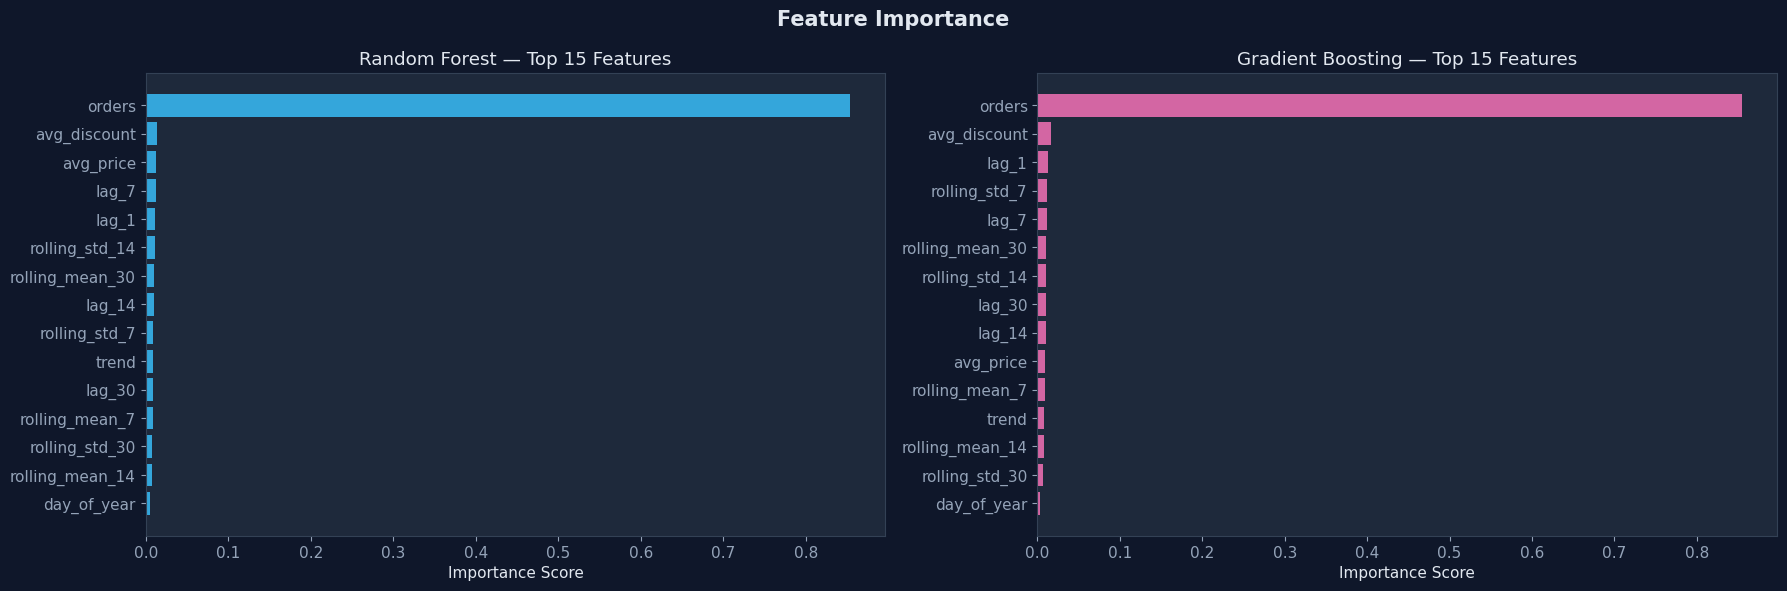

In [68]:
# ── Feature Importance (Random Forest & GBM) ──
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Feature Importance', fontsize=15, fontweight='bold')

for ax, mname, color in zip(axes, ['Random Forest', 'Gradient Boosting'], [PALETTE[0], PALETTE[1]]):
    imp = pd.Series(results[mname]['model'].feature_importances_, index=feature_cols)
    imp = imp.sort_values(ascending=True).tail(15)
    ax.barh(imp.index, imp.values, color=color, alpha=0.85)
    ax.set_title(f'{mname} — Top 15 Features')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [71]:
# ── Recursive multi-step forecasting ──
def generate_forecast(n_days, historical_df, model, feature_cols):
    df = historical_df.copy()
    future_rows = []

    for i in range(1, n_days + 1):
        future_date = df['order_date'].iloc[-1] + pd.Timedelta(days=1)
        row = {
            'order_date'  : future_date,
            'day_of_week' : future_date.dayofweek,
            'month'       : future_date.month,
            'quarter'     : (future_date.month - 1) // 3 + 1,
            'week'        : future_date.isocalendar()[1],
            'year'        : future_date.year,
            'day_of_year' : future_date.timetuple().tm_yday,
            'is_weekend'  : int(future_date.dayofweek >= 5),
            'trend'       : len(df),
            'avg_discount': df['avg_discount'].mean(),
            'avg_price'   : df['avg_price'].mean(),
            'orders'      : df['orders'].mean(),
        }
        # Lag features
        for lag in [1, 7, 14, 30]:
            row[f'lag_{lag}'] = df['demand'].iloc[-lag] if lag <= len(df) else df['demand'].mean()
        # Rolling features
        for win in [7, 14, 30]:
            row[f'rolling_mean_{win}'] = df['demand'].tail(win).mean()
            row[f'rolling_std_{win}']  = df['demand'].tail(win).std()

        # Predict
        X_future = pd.DataFrame([row])[feature_cols]
        row['demand'] = model.predict(X_future)[0]
        future_rows.append(row)

        # Append to history for next iteration
        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)

    return pd.DataFrame(future_rows)

best_model = results[best_name]['model']
forecast_90 = generate_forecast(90, daily_model.copy(), best_model, feature_cols)
forecast_30 = forecast_90.iloc[:30].copy()
forecast_60 = forecast_90.iloc[:60].copy()

print(f"30-day avg forecast: {forecast_30['demand'].mean():.0f} units/day")
print(f"60-day avg forecast: {forecast_60['demand'].mean():.0f} units/day")
print(f"90-day avg forecast: {forecast_90['demand'].mean():.0f} units/day")
forecast_90.head(5)

30-day avg forecast: 4093 units/day
60-day avg forecast: 4087 units/day
90-day avg forecast: 4086 units/day


,order_date,day_of_week,month,quarter,week,year,day_of_year,is_weekend,trend,avg_discount,...,lag_7,lag_14,lag_30,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_30,rolling_std_30,demand
0,2025-01-01,2,1,1,1,2025,1,0,701,0.056254,...,3995.0,4049.0,4338.0,4066.857143,177.838343,4094.642857,148.252699,4103.600000,122.369311,4117.688752
1,2025-01-02,3,1,1,1,2025,2,0,702,0.056254,...,3969.0,4098.0,4213.0,4084.384107,175.607944,4099.549197,147.761775,4096.256292,114.152111,4111.454319
2,2025-01-03,4,1,1,1,2025,3,0,703,0.056254,...,4284.0,4030.0,4128.0,4104.734724,168.101740,4100.510219,147.794673,4092.871436,112.057344,4114.681558
3,2025-01-04,5,1,1,1,2025,4,1,704,0.056254,...,3924.0,4361.0,4031.0,4080.546376,149.117704,4106.558902,146.413370,4092.427488,111.939693,4108.374139
4,2025-01-05,6,1,1,1,2025,5,1,705,0.056254,...,3835.0,4089.0,4006.0,4106.885538,132.179104,4088.514198,126.911185,4095.006626,111.365468,4121.634638


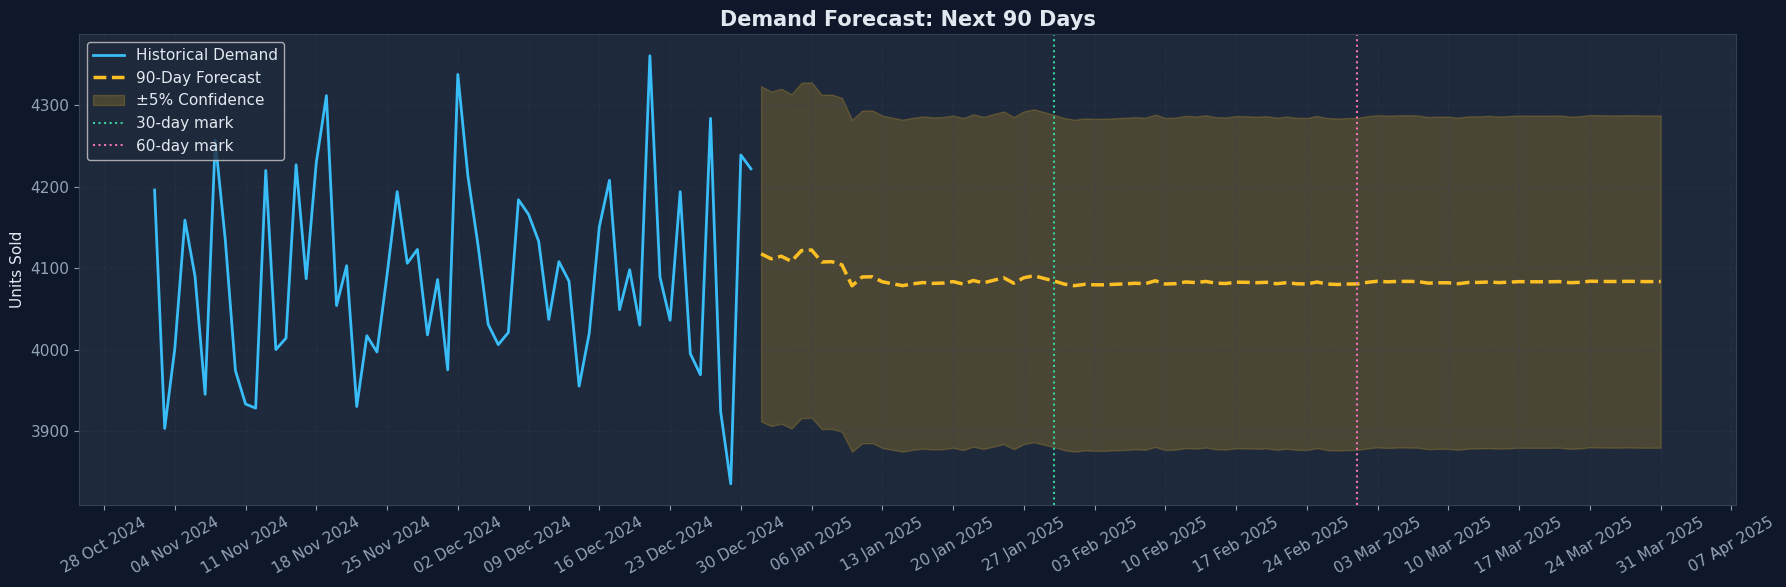

In [72]:
# ── Forecast Plot ──
# Show last 60 days of actual + full 90-day forecast
recent = daily_model.tail(60)

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(recent['order_date'], recent['demand'],
        color=PALETTE[0], linewidth=2, label='Historical Demand')
ax.plot(forecast_90['order_date'], forecast_90['demand'],
        color=PALETTE[3], linewidth=2.5, linestyle='--', label='90-Day Forecast')

# Uncertainty band (±5%)
ax.fill_between(forecast_90['order_date'],
    forecast_90['demand'] * 0.95,
    forecast_90['demand'] * 1.05,
    alpha=0.2, color=PALETTE[3], label='±5% Confidence')

# Vertical lines for 30/60 day markers
ax.axvline(forecast_30['order_date'].iloc[-1], color=PALETTE[2], linestyle=':', linewidth=1.5, label='30-day mark')
ax.axvline(forecast_60['order_date'].iloc[-1], color=PALETTE[1], linestyle=':', linewidth=1.5, label='60-day mark')

ax.set_title('Demand Forecast: Next 90 Days', fontsize=15, fontweight='bold')
ax.set_ylabel('Units Sold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('forecast_90days.png', dpi=150, bbox_inches='tight')
plt.show()

In [75]:
# ── Define thresholds based on historical statistics ──
hist_mean = daily_model['demand'].mean()
hist_std  = daily_model['demand'].std()

OVERSTOCK_THRESH  = hist_mean + 2.0 * hist_std   # Demand > avg+2σ → risk of overstock
UNDERSTOCK_THRESH = hist_mean - 1.5 * hist_std   # Demand < avg-1.5σ → risk of understock

print(f"Historical avg daily demand : {hist_mean:.0f} units")
print(f"Historical std              : {hist_std:.0f} units")
print(f"OVERSTOCK  threshold (>)    : {OVERSTOCK_THRESH:.0f} units")
print(f"UNDERSTOCK threshold (<)    : {UNDERSTOCK_THRESH:.0f} units")

# ── Flag forecast ──
forecast_90['risk_flag'] = 'Normal'
forecast_90.loc[forecast_90['demand'] > OVERSTOCK_THRESH, 'risk_flag'] = '🔴 OVERSTOCK'
forecast_90.loc[forecast_90['demand'] < UNDERSTOCK_THRESH, 'risk_flag'] = '🟡 UNDERSTOCK'

print("\nRisk flag distribution:")
print(forecast_90['risk_flag'].value_counts().to_string())

# Alerts table
alerts = forecast_90[forecast_90['risk_flag'] != 'Normal'][['order_date','demand','risk_flag']]
if not alerts.empty:
    print("\nAlert days:")
    display(alerts)
else:
    print("\n✅ No stock risk alerts in the next 90 days.")

Historical avg daily demand : 4102 units
Historical std              : 122 units
OVERSTOCK  threshold (>)    : 4346 units
UNDERSTOCK threshold (<)    : 3919 units

Risk flag distribution:
risk_flag
Normal    90

✅ No stock risk alerts in the next 90 days.


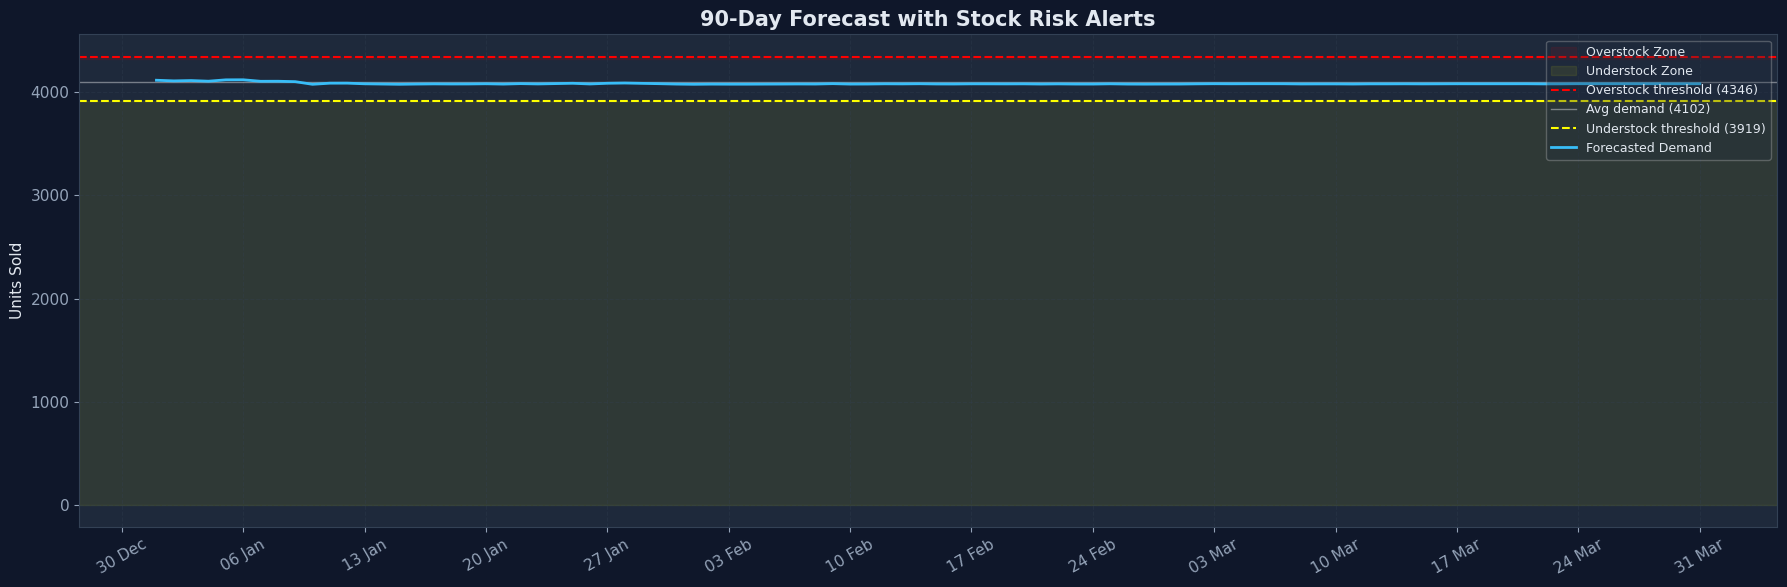

In [77]:
# ── Stock Risk Dashboard Plot ──
fig, ax = plt.subplots(figsize=(18, 6))

# Background zones
ax.axhspan(OVERSTOCK_THRESH,  forecast_90['demand'].max()*1.05, alpha=0.08, color='red',    label='Overstock Zone')
ax.axhspan(0, UNDERSTOCK_THRESH, alpha=0.08, color='yellow', label='Understock Zone')

# Threshold lines
ax.axhline(OVERSTOCK_THRESH,  color='red',    linestyle='--', linewidth=1.5, label=f'Overstock threshold ({OVERSTOCK_THRESH:.0f})')
ax.axhline(hist_mean,          color='white',  linestyle='-',  linewidth=1,   alpha=0.4, label=f'Avg demand ({hist_mean:.0f})')
ax.axhline(UNDERSTOCK_THRESH, color='yellow', linestyle='--', linewidth=1.5, label=f'Understock threshold ({UNDERSTOCK_THRESH:.0f})')

# Forecast line
normal_mask = forecast_90['risk_flag'] == 'Normal'
ax.plot(forecast_90['order_date'], forecast_90['demand'],
        color=PALETTE[0], linewidth=2, label='Forecasted Demand')

# Highlight alert points
overstock_df  = forecast_90[forecast_90['risk_flag'] == '🔴 OVERSTOCK']
understock_df = forecast_90[forecast_90['risk_flag'] == '🟡 UNDERSTOCK']
if not overstock_df.empty:
    ax.scatter(overstock_df['order_date'], overstock_df['demand'], color='red', zorder=5, s=60, label='Overstock Alert')
if not understock_df.empty:
    ax.scatter(understock_df['order_date'], understock_df['demand'], color='yellow', zorder=5, s=60, label='Understock Alert')

ax.set_title('90-Day Forecast with Stock Risk Alerts', fontsize=15, fontweight='bold')
ax.set_ylabel('Units Sold')
ax.legend(loc='upper right', framealpha=0.3, fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('stock_risk_alerts.png', dpi=150, bbox_inches='tight')
plt.show()

In [79]:
import pickle, json, os
os.makedirs('model_outputs', exist_ok=True)

# Save best model
with open('model_outputs/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save processed data
daily_model.to_csv('model_outputs/daily_demand.csv', index=False)
forecast_90.to_csv('model_outputs/forecast_90.csv', index=False)

# Save test predictions
test_results = test[['order_date','demand']].copy()
test_results['predicted'] = results[best_name]['pred']
test_results.to_csv('model_outputs/test_predictions.csv', index=False)

# Save model metadata
metadata = {
    'best_model'      : best_name,
    'feature_cols'    : feature_cols,
    'hist_mean'       : float(hist_mean),
    'hist_std'        : float(hist_std),
    'overstock_thresh': float(OVERSTOCK_THRESH),
    'understock_thresh': float(UNDERSTOCK_THRESH),
    'metrics'         : {k: {'mae': v['mae'], 'rmse': v['rmse'], 'r2': v['r2'], 'mape': v['mape']}
                         for k, v in results.items()}
}
with open('model_outputs/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('✅ All outputs saved to model_outputs/')
print('   - best_model.pkl')
print('   - daily_demand.csv')
print('   - forecast_90.csv')
print('   - test_predictions.csv')
print('   - metadata.json')

✅ All outputs saved to model_outputs/
   - best_model.pkl
   - daily_demand.csv
   - forecast_90.csv
   - test_predictions.csv
   - metadata.json


In [81]:
print('='*60)
print('  DEMAND FORECASTING — FINAL SUMMARY')
print('='*60)
print(f'  Dataset         : 1,000,000 sales transactions')
print(f'  Period          : 2023-01-01 → 2024-12-31')
print(f'  Unique Products : {sales["product_id"].nunique()}')
print(f'  Unique Stores   : {sales["store_id"].nunique()}')
print(f'  Avg Daily Demand: {hist_mean:.0f} units/day')
print()
print('  MODEL RESULTS:')
for name, res in results.items():
    flag = ' 🏆' if name == best_name else ''
    print(f'    {name:22s} MAE={res["mae"]:6.1f}  R²={res["r2"]:.4f}{flag}')
print()
print(f'  FORECAST (next 90 days):')
print(f'    30-day avg : {forecast_30["demand"].mean():.0f} units/day')
print(f'    60-day avg : {forecast_60["demand"].mean():.0f} units/day')
print(f'    90-day avg : {forecast_90["demand"].mean():.0f} units/day')
print()
print(f'  STOCK ALERTS: {len(alerts)} flagged days')
print('='*60)

  DEMAND FORECASTING — FINAL SUMMARY
  Dataset         : 1,000,000 sales transactions
  Period          : 2023-01-01 → 2024-12-31
  Unique Products : 202
  Unique Stores   : 100
  Avg Daily Demand: 4102 units/day

  MODEL RESULTS:
    Random Forest          MAE=  42.3  R²=0.7895 🏆
    Gradient Boosting      MAE=  46.2  R²=0.7403
    Linear Regression      MAE=565163939072.5  R²=-715136611041848459264.0000

  FORECAST (next 90 days):
    30-day avg : 4093 units/day
    60-day avg : 4087 units/day
    90-day avg : 4086 units/day

  STOCK ALERTS: 0 flagged days
